In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score



gdf = gpd.read_file(r"../data/updated_data.geojson")

#fem_house_rate has been deleted because it is obvious that if fem_house_rate is high, ratio_fem_mal will be low
col_to_del_linear_model=['geo_point_2d','urban_type','private_coverage','empl_gap']

gdf.drop(columns=col_to_del_linear_model,inplace=True)

#there is one missing value on ecec_diffusion variable
gdf["ecec_diffusion"] = gdf["ecec_diffusion"].fillna(gdf["ecec_diffusion"].median())



In [2]:


X=gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate','mal_empl_rate'])
y=gdf['fem_empl_rate']
offset=gdf['mal_empl_rate']

# Correlation Part

In [3]:
import numpy as np

#THRESHOLD=0.9
col_to_drop=['empl_rate', 'inact_rate', 'other_per_capita_expenditure', 'adj_net_migration_rate','part_rate','unempl_rate','male_edu_rate']

X.drop(columns=col_to_drop,inplace=True)

corr_matrix=X.corr()

upper_matrix = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

stacked=upper_matrix.stack()
best_pair = stacked.abs().idxmax()
best_corr_value = stacked.loc[best_pair]

print('best_pair',best_pair,'best_corr_value',best_corr_value)

best_pair ('fertility_rate', 'ageing_index') best_corr_value -0.8725350233934767


In [4]:


selected_covariates=X.columns

X = X.to_numpy()
y = y.to_numpy()/100
offset=offset.to_numpy()/100


# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)



y_logit = np.log(y/(1-y)) 
logit_offset=np.log(offset/(1-offset))

y_with_offset = y_logit - logit_offset


n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")



Number of observations: 107, number of predictors: 38


# Frequentist Lasso (Credits : Chi)

Best alpha found: 0.0133

Mean CV R²: 0.553 ± 0.169
Mean CV MSE: 0.022 ± 0.013


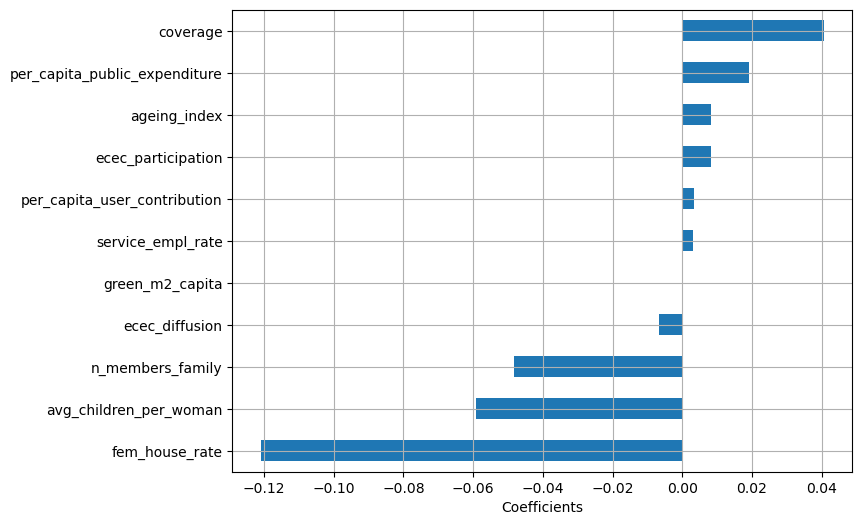

In [5]:


cv = KFold(n_splits=10, shuffle=True, random_state=42)
lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_with_offset)

print(f"Best alpha found: {lasso_cv.alpha_:.4f}")

lasso_final = Lasso(alpha=lasso_cv.alpha_)
lasso_final.fit(X_scaled, y_with_offset)

coef = pd.Series(lasso_final.coef_, index=selected_covariates)
nonzero_coef = coef[coef != 0].sort_values(ascending=False)
# print("\nNon-zero coefficients (variables selected by Lasso):")
# print(nonzero_coef)

r2_scores = cross_val_score(lasso_final, X_scaled, y_with_offset, cv=cv, scoring='r2')
mse_scores = -cross_val_score(lasso_final, X_scaled, y_with_offset, cv=cv, scoring='neg_mean_squared_error')
print(f"\nMean CV R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean CV MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")

plt.figure(figsize=(8,6))
nonzero_coef.sort_values().plot(kind='barh')
# plt.title('Lasso-selected variables influencing ratio female/male employment rate')
plt.xlabel('Coefficients')
plt.grid(True)
plt.show()

/tmp/ipykernel_65740/2468796985.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


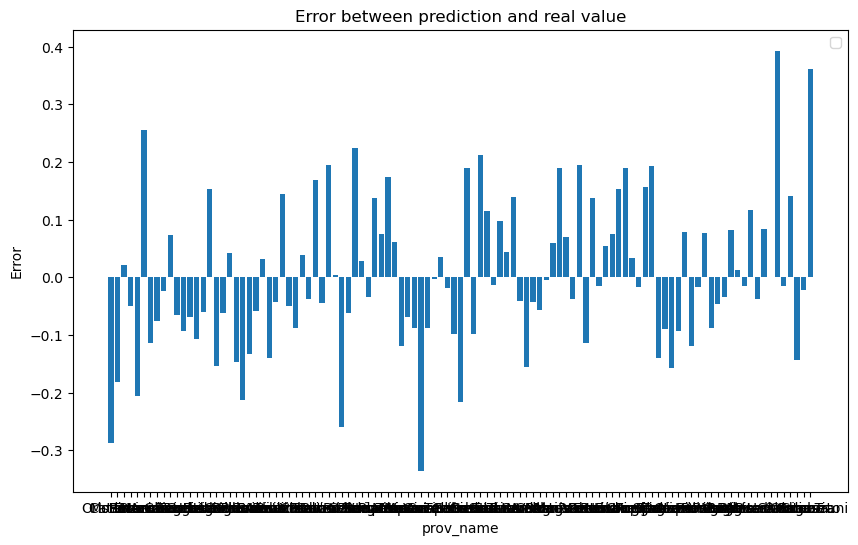

In [6]:
y_pred = lasso_final.predict(X_scaled)

Error=y_pred-y_with_offset


plt.figure(figsize=(10,6))
plt.bar(gdf["prov_name"],Error)
plt.xlabel("prov_name")
plt.ylabel("Error")
plt.title("Error between prediction and real value")
plt.legend()
plt.show()

# Bayes Lasso (Credits : Leo)

In [7]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_logit)

    lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1.0)


    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )

    # intercept = pm.Laplace("alpha", mu=0.0, b=sigma / lambda_)
    intercept = pm.Normal("alpha", mu=0.0, sigma=5.0)

    offset_values = pm.Data("offset", logit_offset)


    mu = pm.math.dot(X_data, beta) + intercept+ offset_values


    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)


    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...


/home/atuan/miniconda3/envs/stan/lib/python3.11/site-packages/pytensor/link/c/cmodule.py:3004: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [lambda, sigma, beta, alpha]


/home/atuan/miniconda3/envs/stan/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 32 seconds.


In [8]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta.index = selected_covariates

summary_beta["contains_zero"] = (
    (summary_beta["hdi_2.5%"] <= 0) &
    (summary_beta["hdi_97.5%"] >= 0)
)

# summary_beta["contains_zero"] = (
#     (summary_beta["hdi_5%"] <= 0) &
#     (summary_beta["hdi_95%"] >= 0)
# )

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])
# print(summary_beta[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])


                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate                     -0.221    -0.323     -0.127          False
avg_children_per_woman             -0.061    -0.112     -0.003          False
n_members_family                   -0.044    -0.098      0.005           True
net_migration_rate                 -0.039    -0.107      0.014           True
ageing_index                        0.033    -0.025      0.102           True
fertility_rate                     -0.025    -0.092      0.029           True
coverage                            0.024    -0.012      0.063           True
ecec_diffusion                     -0.023    -0.056      0.008           True
fem_maj_empl_rate                   0.022    -0.008      0.053           True
per_capita_public_expenditure       0.021    -0.019      0.066           True
foreign_rate                       -0.017    -0.064      0.021           True
ecec_participation                  0.017    -0.025      0.068  

/tmp/ipykernel_65740/1014072038.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


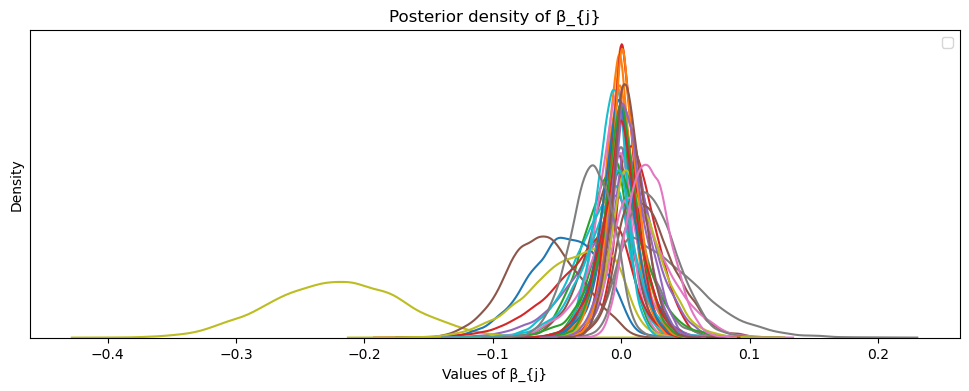

In [9]:


beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))

for i in range(beta_samples.shape[0]):
    # if (selected_covariates[i] in ['empl_rate','coverage','ratio_edu_rate','n_members_family','graduate_mobility_rate']):
    #     sns.kdeplot(beta_samples[i, :],label=selected_covariates[i])
    # else:
        sns.kdeplot(beta_samples[i, :])

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()


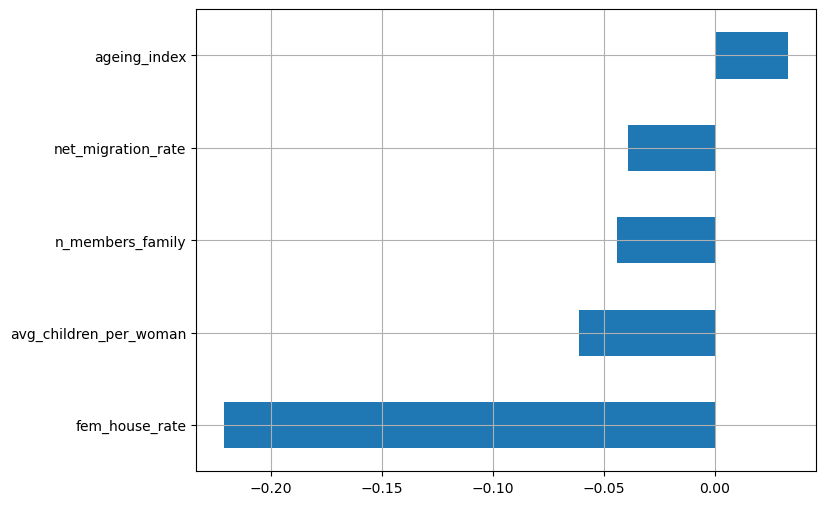

In [10]:
important_covariates=summary_beta[summary_beta["mean"].abs()>0.027]['mean']

plt.figure(figsize=(8,6))
important_covariates.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()

# Spike and Slab

In [11]:
with pm.Model() as ss_model:
    # Data
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_logit)
    offset_vals = pm.Data("offset", logit_offset)

    # Likelihood noise on logit scale
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # ---- Spike-and-Slab Prior ----
    # Inclusion probability (can be hierarchical if you want)
    # pi = pm.Beta("pi", alpha=1, beta=1)   # uniform prior for inclusion
    

    # Spike: indicator for inclusion/exclusion
    # pi = 0.5 # fixed inclusion probability - uniform prior over all the models
    # gamma = pm.Bernoulli("gamma", p=pi, shape=n_feat)
    gamma = pm.Beta("gamma", alpha=0.5, beta=0.5, shape=n_feat)

    # Slab: wide Normal prior for coefficients
    z = pm.Normal("z", mu=0.0, sigma=1.0, shape=n_feat)
    slab_scale = 5.0
    beta_slab = pm.Deterministic("beta_slab", z * slab_scale)

    # Actual beta = spike * slab
    beta = pm.Deterministic("beta", gamma * beta_slab)

    # Intercept: do NOT shrink it
    intercept = pm.Normal("alpha", mu=0.0, sigma=5.0)

    # Linear predictor
    mu = pm.math.dot(X_data, beta) + intercept + offset_vals

    # Likelihood: Gaussian on logit-transformed employment rate
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    # Sampling
    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.999,
        nuts={"max_treedepth": 18},  
        return_inferencedata=True,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, gamma, z, alpha]


/home/atuan/miniconda3/envs/stan/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/atuan/miniconda3/envs/stan/lib/python3.11/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1994 seconds.


In [12]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta.index = selected_covariates

summary_beta["contains_zero"] = (
    (summary_beta["hdi_2.5%"] <= 0) &
    (summary_beta["hdi_97.5%"] >= 0)
)

# summary_beta["contains_zero"] = (
#     (summary_beta["hdi_5%"] <= 0) &
#     (summary_beta["hdi_95%"] >= 0)
# )

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])
# print(summary_beta[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])


                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate                     -0.363    -0.452     -0.271          False
ageing_index                        0.143    -0.007      0.264           True
net_migration_rate                 -0.119    -0.191     -0.035          False
dependency_rate                    -0.083    -0.169      0.008           True
n_members_family                   -0.066    -0.131      0.003           True
fertility_rate                     -0.060    -0.174      0.031           True
GDP                                -0.051    -0.141      0.020           True
avg_children_per_woman             -0.049    -0.133      0.014           True
fem_maj_empl_rate                   0.032    -0.003      0.066           True
ecec_participation                  0.027    -0.027      0.093           True
young_neet                          0.024    -0.017      0.081           True
ecec_diffusion                     -0.023    -0.061      0.009  

/tmp/ipykernel_65740/1014072038.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


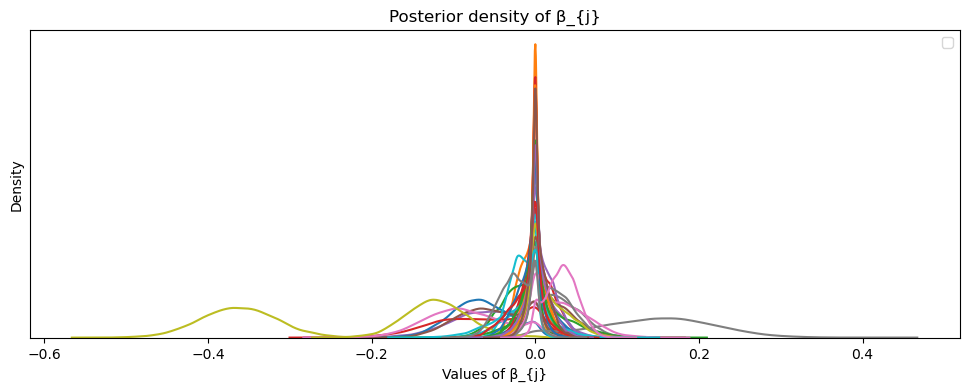

In [13]:


beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))

for i in range(beta_samples.shape[0]):
    # if (selected_covariates[i] in ['empl_rate','coverage','ratio_edu_rate','n_members_family','graduate_mobility_rate']):
    #     sns.kdeplot(beta_samples[i, :],label=selected_covariates[i])
    # else:
        sns.kdeplot(beta_samples[i, :])

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()


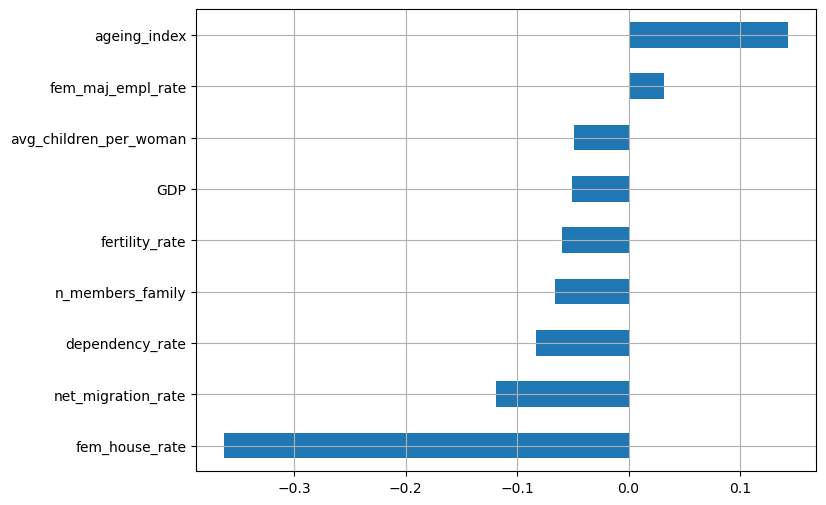

In [14]:
important_covariates=summary_beta[summary_beta["mean"].abs()>0.027]['mean']

plt.figure(figsize=(8,6))
important_covariates.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()

# Horseshoe

In [15]:
with pm.Model() as hs_model:
    # Data
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_logit)
    offset_vals = pm.Data("offset", logit_offset)

    # Likelihood noise on logit scale
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    # ---- Horseshoe Prior for beta ----
    #tau = pm.HalfCauchy("tau", beta=1.0)  # global shrinkage
    #lam = pm.HalfCauchy("lam", beta=1.0, shape=n_feat)  # local shrinkage
    tau_raw = pm.HalfNormal("tau_raw", sigma=1.0)
    tau = pm.Deterministic("tau", tau_raw)

    lam_raw = pm.HalfNormal("lam_raw", sigma=1.0, shape=n_feat)
    lam = pm.Deterministic("lam", lam_raw)

    # actual beta
    z = pm.Normal("z", 0.0, 1.0, shape=n_feat)  # standard normal
    beta = pm.Deterministic("beta", z * tau * lam)  # non-centered

    # Intercept
    intercept = pm.Normal("alpha", mu=0.0, sigma=5.0)

    # Linear predictor
    mu = pm.math.dot(X_data, beta) + intercept + offset_vals

    # Likelihood: Gaussian on logit-transformed outcome
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)

    # Sampling
    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.999,
        nuts={"max_treedepth": 18},  
        return_inferencedata=True,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, tau_raw, lam_raw, z, alpha]


/home/atuan/miniconda3/envs/stan/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 132 seconds.


In [16]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.95)

summary_beta.index = selected_covariates

summary_beta["contains_zero"] = (
    (summary_beta["hdi_2.5%"] <= 0) &
    (summary_beta["hdi_97.5%"] >= 0)
)

# summary_beta["contains_zero"] = (
#     (summary_beta["hdi_5%"] <= 0) &
#     (summary_beta["hdi_95%"] >= 0)
# )

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])
# print(summary_beta[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])


                                     mean  hdi_2.5%  hdi_97.5%  contains_zero
fem_house_rate                     -0.246    -0.338     -0.148          False
avg_children_per_woman             -0.069    -0.120      0.001           True
n_members_family                   -0.051    -0.106      0.005           True
net_migration_rate                 -0.051    -0.124      0.008           True
ageing_index                        0.040    -0.019      0.123           True
fertility_rate                     -0.026    -0.107      0.030           True
fem_maj_empl_rate                   0.022    -0.005      0.055           True
coverage                            0.021    -0.011      0.061           True
ecec_diffusion                     -0.020    -0.055      0.008           True
per_capita_public_expenditure       0.019    -0.017      0.067           True
foreign_rate                       -0.017    -0.064      0.021           True
GDP                                -0.017    -0.081      0.025  

/tmp/ipykernel_65740/1014072038.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


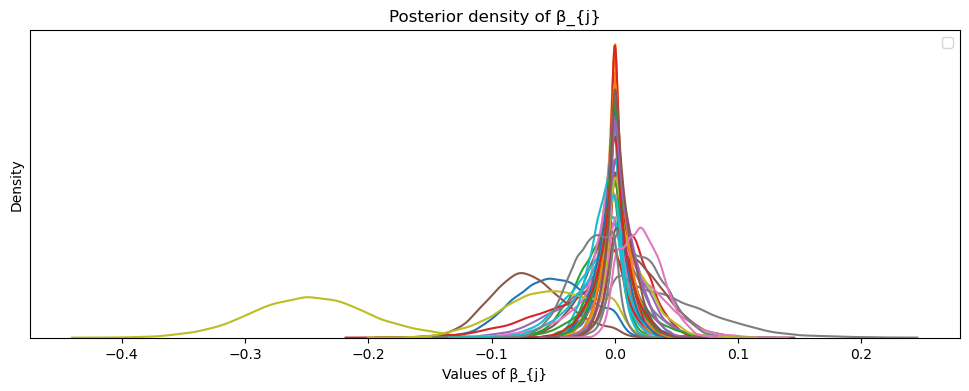

In [17]:


beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))

for i in range(beta_samples.shape[0]):
    # if (selected_covariates[i] in ['empl_rate','coverage','ratio_edu_rate','n_members_family','graduate_mobility_rate']):
    #     sns.kdeplot(beta_samples[i, :],label=selected_covariates[i])
    # else:
        sns.kdeplot(beta_samples[i, :])

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()


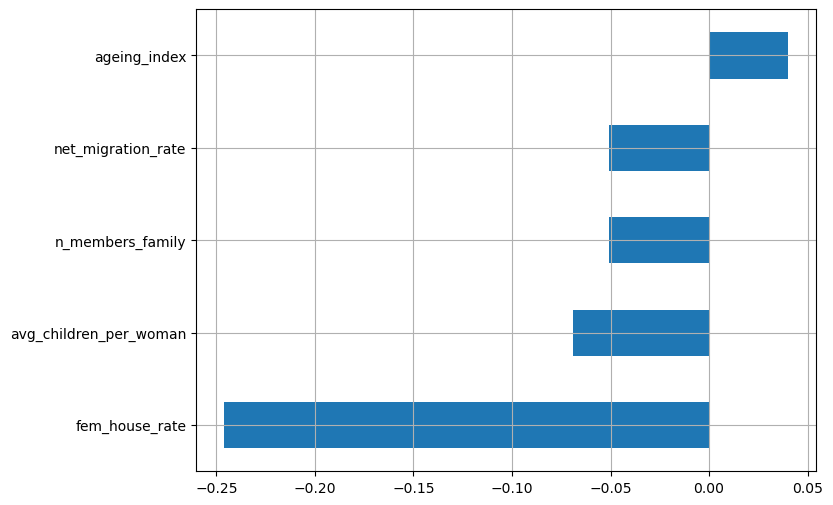

In [18]:
important_covariates=summary_beta[summary_beta["mean"].abs()>0.027]['mean']

plt.figure(figsize=(8,6))
important_covariates.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()